## Import Libraries

In [1]:
# Add package to path
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from galform_analysis.config import get_base_dir
from galform_analysis.analysis.mass_functions import hmf_given_redshift_and_subvolume
from galform_analysis.analysis import hmfs_given_redshifts_and_subvolume

project_root = Path.cwd().parent
if str(project_root / 'src') not in sys.path:
    sys.path.insert(0, str(project_root / 'src'))

# Set up plotting
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11

# The BASE_DIR is already configured in config.py
base_dir = get_base_dir()

# Optional lower mass cut (same units as mhalo, typically h^-1 M_sun)
# Set to None to use all halos, or a value like 1e10 to drop low-mass halos
halo_mass_lower_limit = None

## For a given redshift and sub volume, plot the HMF

Redshift z = 4.301
Volume V_ivol = 1.556e+05 Mpc^3
Total halos counted: 964


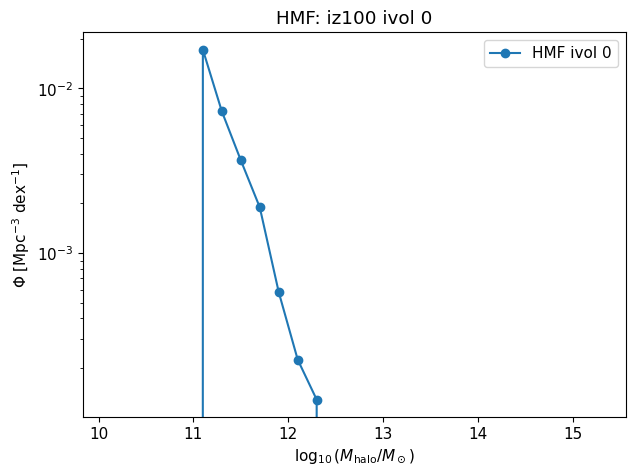

In [2]:
halo_mass_lower_limit = 1e11

example_snapshot = 'iz100'
example_ivol = 0  

result = hmf_given_redshift_and_subvolume(
    str(base_dir / example_snapshot),
    example_ivol,
    halo_mass_lower_limit=halo_mass_lower_limit,
    )

if result is None:
    print("No valid HMF data for this (snapshot, ivol). Try another ivol or snapshot.")
else:
    z_val = result.get('z')
    centers = result['centers']
    phi = result['phi']
    counts = result['counts']
    V_ivol = result.get('V_ivol')

    if z_val is not None:
        print(f"Redshift z = {z_val:.3f}")
    if V_ivol is not None:
        print(f"Volume V_ivol = {V_ivol:.3e} Mpc^3")
    print(f"Total halos counted: {counts.sum()}")

    fig, ax = plt.subplots(figsize=(7,5))
    ax.set_yscale('log')
    ax.plot(centers, phi, 'o-', label=f'HMF ivol {example_ivol}')

    ax.set_xlabel(r'$\log_{10}(M_{\rm halo}/M_\odot)$')
    ax.set_ylabel(r'$\Phi$ [Mpc$^{-3}$ dex$^{-1}$]')
    title = f"HMF: {example_snapshot} ivol {example_ivol}"
    ax.set_title(title)
    ax.legend()
    plt.show()

## For a given redshift and subvolume, compare to theoretical HMFs

/cosma/home/durham/dc-hick2/galform_analysis/.venv/lib64/python3.9/site-packages/hmf/density_field/transfer_models.py:232: UserWarning: 'extrapolate_with_eh' was not set. Defaulting to True, which is different behaviour than versions <=3.4.4. This warning may be removed in v4.0. Silence it by setting extrapolate_with_eh explicitly.
  warnings.warn(


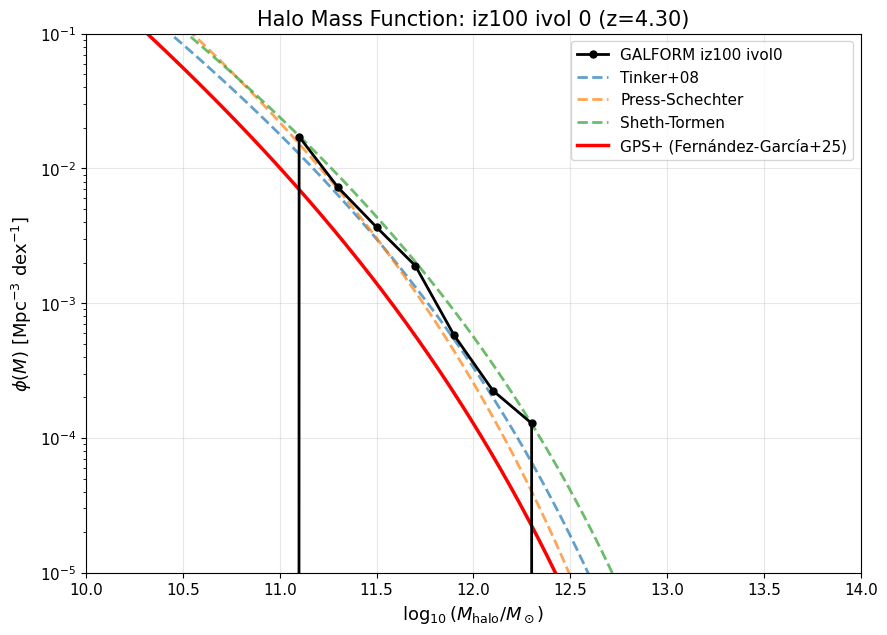


Loaded 27 mass bins
Redshift: z = 4.30
Volume: V = 1.56e+05 (Mpc/h)^3


In [ ]:
example_snapshot = 'iz100'
example_ivol = 0  

result = hmf_given_redshift_and_subvolume(
    str(base_dir / example_snapshot),
    example_ivol,
    halo_mass_lower_limit=halo_mass_lower_limit,
    )

if result is None:
    print("No valid HMF data for this (snapshot, ivol). Try another ivol or snapshot.")
else:
    z_val = result.get('z')
    centers = result['centers']
    phi = result['phi']
    counts = result['counts']
    V_ivol = result.get('V_ivol')
    
    # Compute theoretical HMFs using the new module
    from galform_analysis.analysis.mass_functions import compute_theoretical_hmfs
    
    theoretical = compute_theoretical_hmfs(
        z=z_val,
        bins=np.arange(9.0, 15.0, 0.2),
        hmf_models='all',  # Compute PS, ST, Tinker08, and GPS+
        cosmo_params={
            'H0': 70.0,
            'Om0': 0.3,
            'Ob0': 0.045,
        },
        sigma_8=0.8,
        n=0.96,
    )
    
    # Extract theoretical curves
    log10M_theory = theoretical['centers']
    phi_ps = theoretical['PS']
    phi_st = theoretical['ST']
    phi_tinker = theoretical['Tinker08']
    phi_gps = theoretical['GPS+']
    
    # Plot comparison
    fig, ax = plt.subplots(figsize=(10, 7))
    
    # GALFORM data
    ax.plot(centers, phi, 'o-', label=f'GALFORM {example_snapshot} ivol{example_ivol}', 
            linewidth=2, markersize=5, color='black', zorder=10)
    
    # Theory curves
    ax.plot(log10M_theory, phi_tinker, '--', label='Tinker+08', linewidth=2, alpha=0.7)
    ax.plot(log10M_theory, phi_ps, '--', label='Press-Schechter', linewidth=2, alpha=0.7)
    ax.plot(log10M_theory, phi_st, '--', label='Sheth-Tormen', linewidth=2, alpha=0.7)
    ax.plot(log10M_theory, phi_gps, '-', label='GPS+ (Fernández-García+25)', linewidth=2.5, color='red')
    
    ax.set_yscale('log')
    ax.set_xlim(10, 14)  # Focus on the range where data exists
    ax.set_ylim(1e-5, 1e-1)  # Focus on the range where data exists
    ax.set_xlabel(r'$\log_{10}(M_{\rm halo} / M_\odot)$', fontsize=13)
    ax.set_ylabel(r'$\phi(M)$ [Mpc$^{-3}$ dex$^{-1}$]', fontsize=13)
    
    title = f"Halo Mass Function: {example_snapshot} ivol {example_ivol}"
    if z_val is not None:
        title += f" (z={z_val:.2f})"
    ax.set_title(title, fontsize=15)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    
    plt.show()
    
    print(f"\nLoaded {len(centers)} mass bins")
    print(f"Redshift: z = {z_val:.2f}" if z_val is not None else "Redshift: unknown")
    print(f"Volume: V = {V_ivol:.2e} (Mpc/h)^3" if V_ivol else "Volume: unknown")

## HMFs for different redshifts

Computing HMF for ivol=0 at 3 redshifts
Successfully loaded 2 snapshots


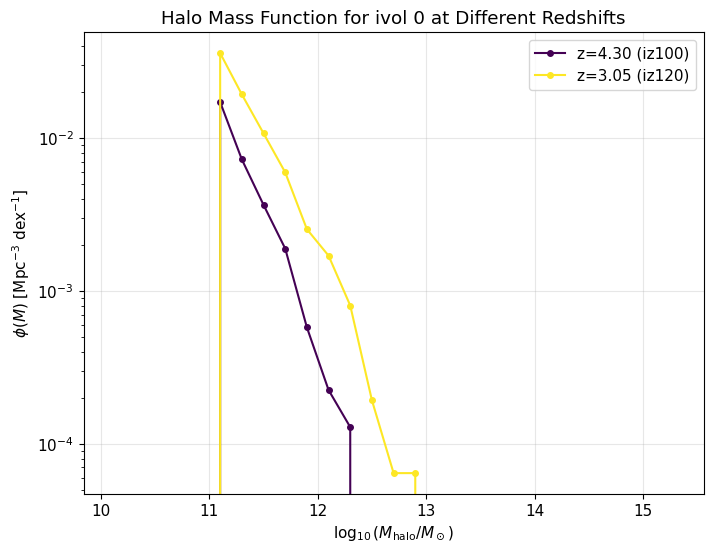

In [4]:
# Set lower mass limit for this analysis
halo_mass_lower_limit = 1e11

example_ivol = 0
iz_nums = [82, 100, 120]  # subset for faster testing

print(f"Computing HMF for ivol={example_ivol} at {len(iz_nums)} redshifts")

# Collect results for each redshift
df, results_by_z = hmfs_given_redshifts_and_subvolume(
    example_ivol,
    iz_nums,
    base_dir=base_dir,
    halo_mass_lower_limit=halo_mass_lower_limit,
    )
    
# Plot each redshift separately on same axes
fig, ax = plt.subplots(figsize=(8,6))
colors = plt.cm.viridis(np.linspace(0, 1, len(results_by_z)))

for res, color in zip(results_by_z, colors):
    label = f"z={res['z']:.2f} ({res['iz']})"
    ax.plot(res['centers'], res['phi'], 'o-', label=label, color=color, markersize=4)

ax.set_yscale('log')
ax.set_xlabel(r'$\log_{10}(M_{\rm halo}/M_\odot)$')
ax.set_ylabel(r'$\phi(M)$ [Mpc$^{-3}$ dex$^{-1}$]')
ax.set_title(f'Halo Mass Function for ivol {example_ivol} at Different Redshifts')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

## For a given sub volume average over given redshifts

Computing HMF for ivol=0 across 3 redshifts
Successfully used 2/3 snapshots
Snapshots: ['iz100', 'iz120']
Redshifts: ['4.30', '3.05']


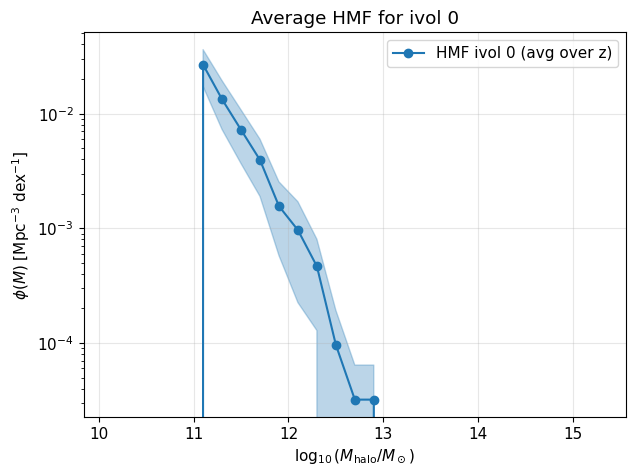

In [5]:
# Example: Average HMF for one subvolume across multiple redshifts
from galform_analysis.analysis import avg_hmf_given_redshifts_and_subvolume

example_ivol = 0  # choose a subvolume
iz_nums = [82, 100, 120]  # snapshots that exist in base_dir

print(f"Computing HMF for ivol={example_ivol} across {len(iz_nums)} redshifts")

result = avg_hmf_given_redshifts_and_subvolume(
    example_ivol,
    iz_nums,
    halo_mass_lower_limit=halo_mass_lower_limit,
    )

if result is None:
    print("No valid HMF data. Check that the subvolume exists in these snapshots.")
else:
    print(f"Successfully used {result['n_used']}/{result['n_requested']} snapshots")
    print(f"Snapshots: {result['iz_list']}")
    print(f"Redshifts: {[f'{z:.2f}' for z in result['z_list']]}")
    
    centers = result['centers']
    phi = result['phi']
    phi_std = result['phi_std']
    
    fig, ax = plt.subplots(figsize=(7,5))
    ax.set_yscale('log')
    ax.plot(centers, phi, 'o-', label=f'HMF ivol {example_ivol} (avg over z)', color='C0')
    ax.fill_between(centers, phi - phi_std, phi + phi_std, alpha=0.3, color='C0')
    ax.set_xlabel(r'$\log_{10}(M_{\rm halo}/M_\odot)$')
    ax.set_ylabel(r'$\phi(M)$ [Mpc$^{-3}$ dex$^{-1}$]')
    ax.set_title(f'Average HMF for ivol {example_ivol}')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.show()